# FASE 3 — Personalized Clinical Decision Support System (PCDSS)

De *predicción/monitoreo* a **recomendación clínica asistida**: responde *¿qué debería hacerse con este paciente?*. **No** diagnostica ni reemplaza al médico; cada salida es **explicable y auditable**. Integra el riesgo (FASE 1) y la evolución (FASE 2) sobre la cohorte enriquecida con consultas, medicación, adherencia y comorbilidades.

## 01 — Clinical Rule Engine (Fase 3A)

Motor de reglas declarativo `IF condición THEN alerta/acción`, con severidad, acción recomendada y **evidencia** (los valores que la dispararon → rule trace auditable).

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

CD = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CD / "src"))
from predia_cdss import config
DS, MET, FIG, RUL, DASH = CD/"datasets", CD/"metrics", CD/"figures", CD/"rules", CD/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)
print("Entorno listo:", CD)


Entorno listo: /home/wowo/Descargas/predia/ml-research/clinical_decision_support


## Catálogo de reglas

In [2]:
rc = load(RUL/'rules_catalog.json'); pd.DataFrame(rc)

,id,name,severity,action,message,priority_flag
0,R01,Hiperglucemia + obesidad,warning,revisar_tratamiento,Glucosa e IMC elevados de forma simultánea,False
1,R02,PA elevada persistente (3 consultas),warning,programar_consulta,Presión arterial elevada en las últimas 3 cons...,True
2,R03,Riesgo muy alto sin consulta reciente,critical,contacto_preventivo,Riesgo muy alto y sin consulta reciente → suge...,True
3,R04,Glucosa muy alta,critical,revisar_tratamiento,Glucosa en rango muy alto: revisar tratamiento...,False
4,R05,Crisis hipertensiva,critical,derivar_especialista,Presión arterial en rango de crisis,True
5,R06,Baja adherencia con tratamiento activo,warning,reforzar_adherencia,Adherencia por debajo del umbral con medicació...,False
6,R07,Evolución desfavorable (CES bajo),warning,evaluar_factores,Clinical Evolution Score bajo: deterioro de la...,True
7,R08,Tendencia glucémica creciente,warning,revisar_tratamiento,Glucosa con pendiente creciente sostenida,False
8,R09,Sedentarismo,info,educacion_habitos,Actividad física por debajo de lo recomendado,False
9,R10,Datos clínicos desactualizados,info,actualizar_glucosa,Sin registros recientes: actualizar glucosa/si...,False


## Frecuencia de disparo en la cohorte

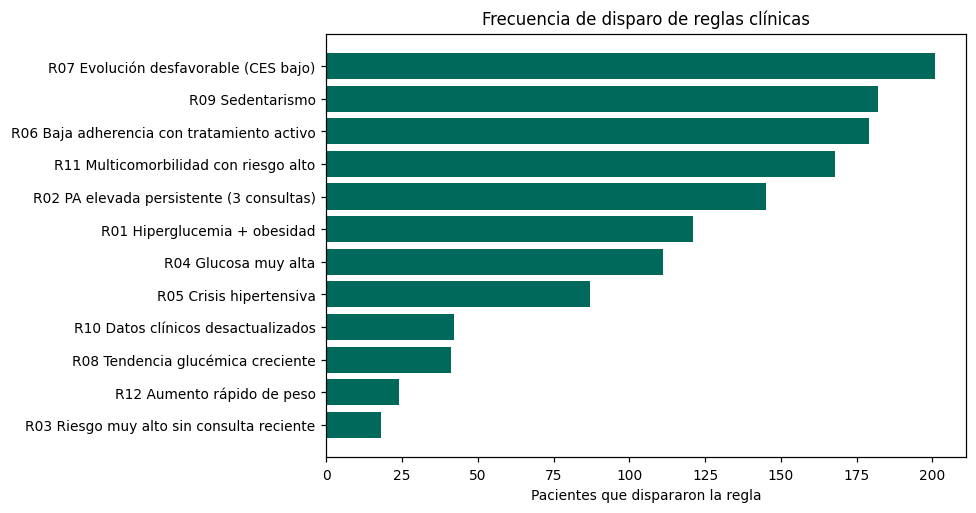

In [3]:
show(FIG/'rules'/'rule_frequency.png')

## Rule trace de un paciente (auditable)

In [4]:
ff = load(MET/'rule_firings.json')
pid = next(k for k,v in ff.items() if len(v)>=3)
print('Paciente', pid)
for r in ff[pid]:
    print(f"  [{r['severity']:8s}] {r['rule_id']} {r['name']} -> {r['action']}")
    print(f"      evidencia: {r['evidence']}")

Paciente 1
  [critical] R04 Glucosa muy alta -> revisar_tratamiento
      evidencia: {'glucosa': 272.71}
  [warning ] R01 Hiperglucemia + obesidad -> revisar_tratamiento
      evidencia: {'glucosa': 272.71, 'imc': 36.75}
  [warning ] R02 PA elevada persistente (3 consultas) -> programar_consulta
      evidencia: {'pa_elevated_last3': True, 'pas_actual': 153.69}
  [warning ] R06 Baja adherencia con tratamiento activo -> reforzar_adherencia
      evidencia: {'adherencia': 0.644, 'n_medicacion': 3}
  [warning ] R07 Evolución desfavorable (CES bajo) -> evaluar_factores
      evidencia: {'ces': 15.6, 'banda': 'Deterioro severo'}
  [warning ] R11 Multicomorbilidad con riesgo alto -> derivar_especialista
      evidencia: {'comorbilidades': 'Hipertensión|Obesidad|Dislipidemia', 'riesgo': 1.0}
  [info    ] R09 Sedentarismo -> educacion_habitos
      evidencia: {'actividad': 17.31}


### Conclusión 3A
Las reglas convierten umbrales clínicos en alertas trazables; cada disparo cita su evidencia, base de la auditabilidad.